In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Environment ready")

Environment ready


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [ ]:
orders = pd.read_csv("Orders.csv")
details = pd.read_csv("Details.csv")

In [ ]:
orders.head()

,Order ID,Order Date,CustomerName,State,City
0,B-26055,10-03-2018,Harivansh,Uttar Pradesh,Mathura
1,B-25993,03-02-2018,Madhav,Delhi,Delhi
2,B-25973,24-01-2018,Madan Mohan,Uttar Pradesh,Mathura
3,B-25923,27-12-2018,Gopal,Maharashtra,Mumbai
4,B-25757,21-08-2018,Vishakha,Madhya Pradesh,Indore


In [ ]:
details.head()

,Order ID,Amount,Profit,Quantity,Category,Sub-Category,PaymentMode
0,B-25681,1096,658,7,Electronics,Electronic Games,COD
1,B-26055,5729,64,14,Furniture,Chairs,EMI
2,B-25955,2927,146,8,Furniture,Bookcases,EMI
3,B-26093,2847,712,8,Electronics,Printers,Credit Card
4,B-25602,2617,1151,4,Electronics,Phones,Credit Card


In [ ]:
orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   Order ID      500 non-null    str  
 1   Order Date    500 non-null    str  
 2   CustomerName  500 non-null    str  
 3   State         500 non-null    str  
 4   City          500 non-null    str  
dtypes: str(5)
memory usage: 19.7 KB


In [ ]:
details.info()

<class 'pandas.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   Order ID      1500 non-null   str  
 1   Amount        1500 non-null   int64
 2   Profit        1500 non-null   int64
 3   Quantity      1500 non-null   int64
 4   Category      1500 non-null   str  
 5   Sub-Category  1500 non-null   str  
 6   PaymentMode   1500 non-null   str  
dtypes: int64(3), str(4)
memory usage: 82.2 KB


In [ ]:
orders.describe()

,Order ID,Order Date,CustomerName,State,City
count,500,500,500,500,500
unique,500,307,336,19,25
top,B-26055,24-11-2018,Shreya,Maharashtra,Indore
freq,1,7,6,94,71


In [ ]:
details.describe()

,Amount,Profit,Quantity
count,1500.000000,1500.00000,1500.000000
mean,291.847333,24.64200,3.743333
std,461.924620,168.55881,2.184942
min,4.000000,-1981.00000,1.000000
25%,47.750000,-12.00000,2.000000
50%,122.000000,8.00000,3.000000
75%,326.250000,38.00000,5.000000
max,5729.000000,1864.00000,14.000000


In [ ]:
orders.columns

Index(['Order ID', 'Order Date', 'CustomerName', 'State', 'City'], dtype='str')

In [ ]:
details.columns

Index(['Order ID', 'Amount', 'Profit', 'Quantity', 'Category', 'Sub-Category',
       'PaymentMode'],
      dtype='str')

In [ ]:
df = pd.merge(orders, details, on="Order ID")

In [ ]:
df.head()

,Order ID,Order Date,CustomerName,State,City,Amount,Profit,Quantity,Category,Sub-Category,PaymentMode
0,B-26055,10-03-2018,Harivansh,Uttar Pradesh,Mathura,5729,64,14,Furniture,Chairs,EMI
1,B-26055,10-03-2018,Harivansh,Uttar Pradesh,Mathura,671,114,9,Electronics,Phones,Credit Card
2,B-26055,10-03-2018,Harivansh,Uttar Pradesh,Mathura,443,11,1,Clothing,Saree,COD
3,B-26055,10-03-2018,Harivansh,Uttar Pradesh,Mathura,57,7,2,Clothing,Shirt,UPI
4,B-26055,10-03-2018,Harivansh,Uttar Pradesh,Mathura,227,48,5,Clothing,Stole,COD


In [ ]:
df["Revenue"] = df["Amount"]

In [ ]:
df.head()

,Order ID,Order Date,CustomerName,State,City,Amount,Profit,Quantity,Category,Sub-Category,PaymentMode,Revenue
0,B-26055,10-03-2018,Harivansh,Uttar Pradesh,Mathura,5729,64,14,Furniture,Chairs,EMI,5729
1,B-26055,10-03-2018,Harivansh,Uttar Pradesh,Mathura,671,114,9,Electronics,Phones,Credit Card,671
2,B-26055,10-03-2018,Harivansh,Uttar Pradesh,Mathura,443,11,1,Clothing,Saree,COD,443
3,B-26055,10-03-2018,Harivansh,Uttar Pradesh,Mathura,57,7,2,Clothing,Shirt,UPI,57
4,B-26055,10-03-2018,Harivansh,Uttar Pradesh,Mathura,227,48,5,Clothing,Stole,COD,227


In [ ]:
df["Revenue"].sum()

np.int64(437771)

In [ ]:
category_sales = df.groupby("Category")["Revenue"].sum().sort_values(ascending=False)
category_sales

Category
Electronics    166267
Clothing       144323
Furniture      127181
Name: Revenue, dtype: int64

In [ ]:
df.isnull().sum()

Order ID        0
Order Date      0
CustomerName    0
State           0
City            0
Amount          0
Profit          0
Quantity        0
Category        0
Sub-Category    0
PaymentMode     0
Revenue         0
dtype: int64

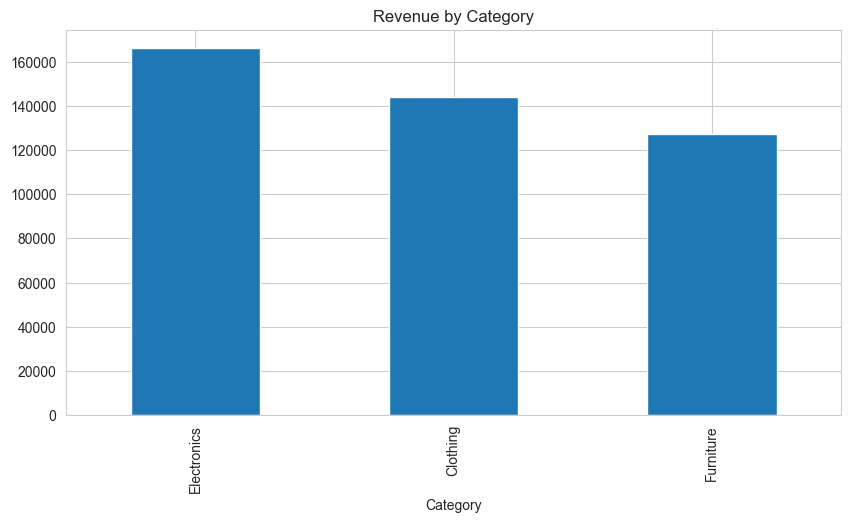

In [ ]:
category_sales.plot(kind="bar", figsize=(10,5))
plt.title("Revenue by Category")
plt.show()

In [ ]:
df["Order Date"] = pd.to_datetime(df["Order Date"], format="%d-%m-%Y")

In [ ]:
df["Year"] = df["Order Date"].dt.year
df["Month"] = df["Order Date"].dt.month
df["MonthName"] = df["Order Date"].dt.month_name()

In [ ]:
df["Revenue"] = df["Amount"]

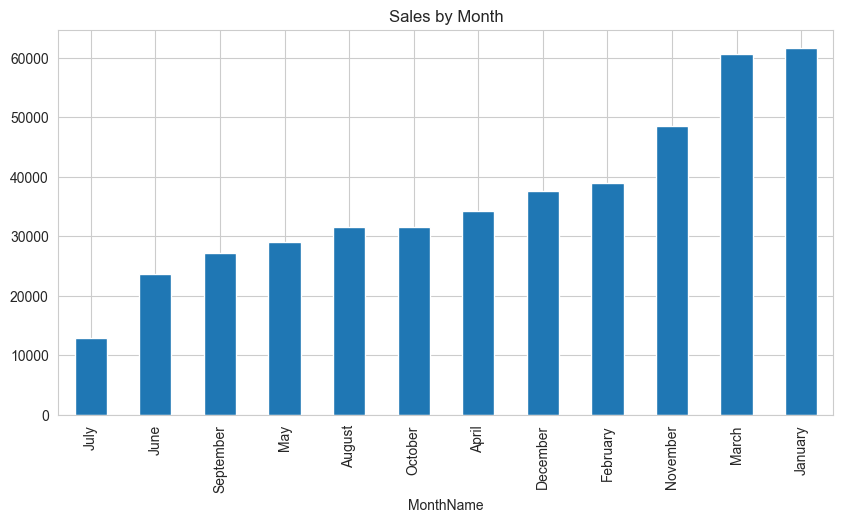

In [ ]:
monthly_sales = df.groupby("MonthName")["Revenue"].sum().sort_values()
monthly_sales.plot(kind="bar", figsize=(10,5))
plt.title("Sales by Month")
plt.show()

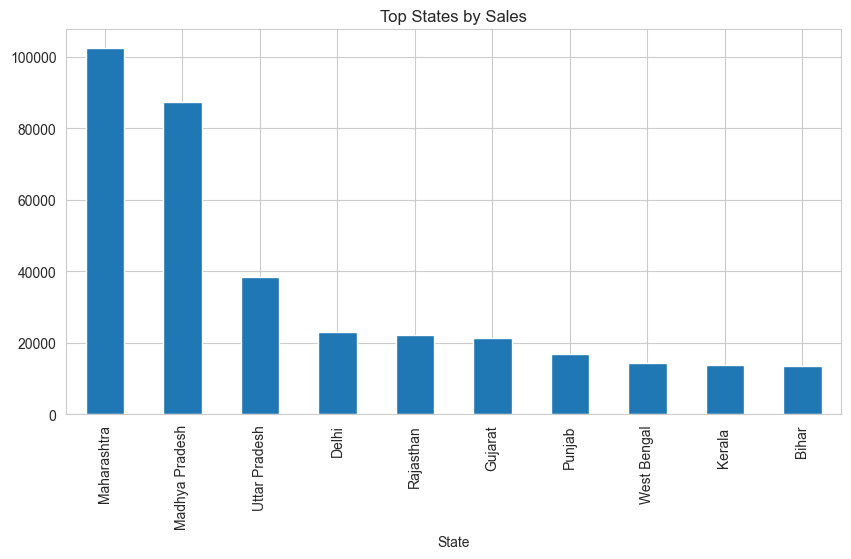

In [ ]:
region_sales = df.groupby("State")["Revenue"].sum().sort_values(ascending=False).head(10)
region_sales.plot(kind="bar", figsize=(10,5))
plt.title("Top States by Sales")
plt.show()

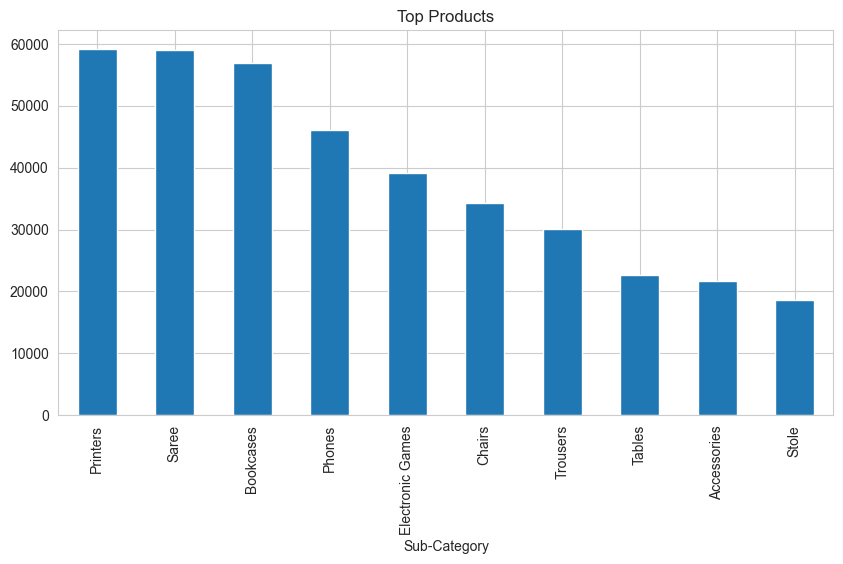

In [ ]:
top_products = df.groupby("Sub-Category")["Revenue"].sum().sort_values(ascending=False).head(10)
top_products.plot(kind="bar", figsize=(10,5))
plt.title("Top Products")
plt.show()

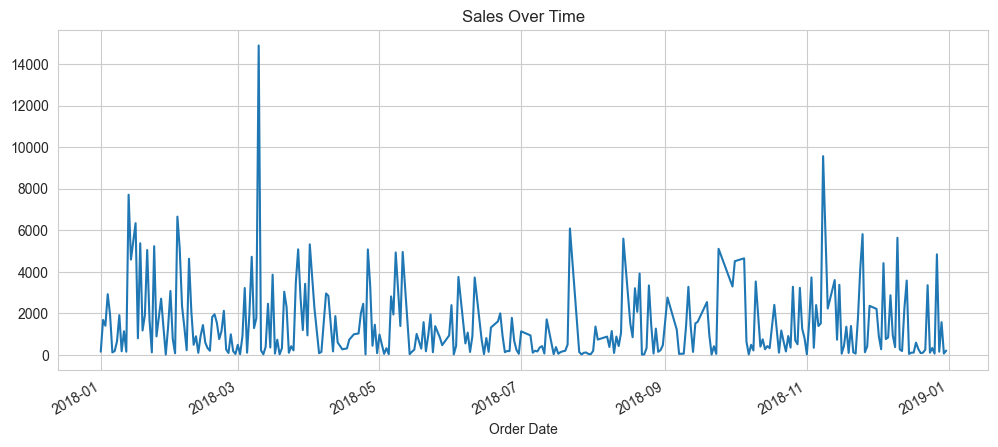

In [ ]:
time_sales = df.groupby("Order Date")["Revenue"].sum()
time_sales.plot(figsize=(12,5))
plt.title("Sales Over Time")
plt.show()

In [ ]:
df["Order Date"] = pd.to_datetime(df["Order Date"])

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Order ID      1500 non-null   str           
 1   Order Date    1500 non-null   datetime64[us]
 2   CustomerName  1500 non-null   str           
 3   State         1500 non-null   str           
 4   City          1500 non-null   str           
 5   Amount        1500 non-null   int64         
 6   Profit        1500 non-null   int64         
 7   Quantity      1500 non-null   int64         
 8   Category      1500 non-null   str           
 9   Sub-Category  1500 non-null   str           
 10  PaymentMode   1500 non-null   str           
 11  Revenue       1500 non-null   int64         
 12  Year          1500 non-null   int32         
 13  Month         1500 non-null   int32         
 14  MonthName     1500 non-null   str           
dtypes: datetime64[us](1), int32(2), int64(4), str(8)


In [ ]:
df["Year"] = df["Order Date"].dt.year
df["Month"] = df["Order Date"].dt.month
df["MonthName"] = df["Order Date"].dt.strftime("%B")

In [ ]:
monthly_sales = df.groupby(["Year","Month"])["Revenue"].sum().reset_index()
monthly_sales

,Year,Month,Revenue
0,2018,1,61632
1,2018,2,38962
2,2018,3,60694
3,2018,4,34330
4,2018,5,29093
5,2018,6,23658
6,2018,7,12966
7,2018,8,31492
8,2018,9,27283
9,2018,10,31613


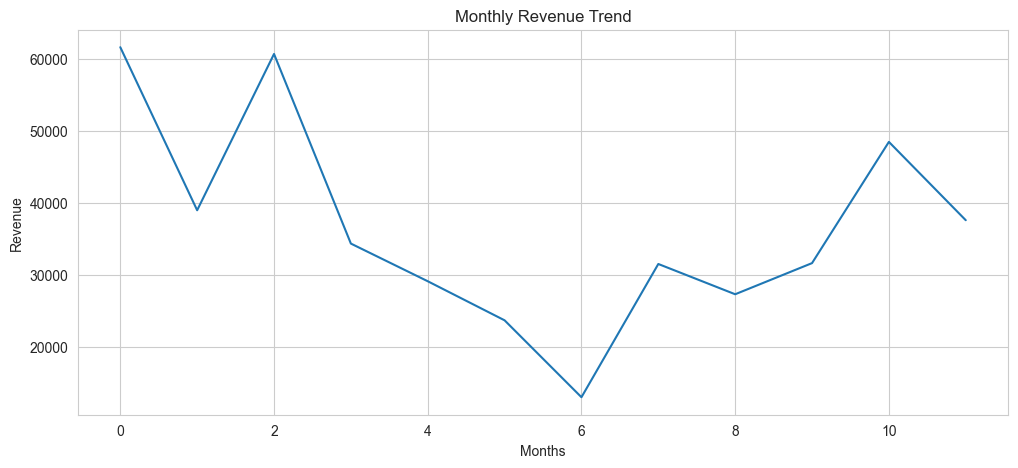

In [ ]:
plt.figure(figsize=(12,5))
plt.plot(monthly_sales["Revenue"])
plt.title("Monthly Revenue Trend")
plt.xlabel("Months")
plt.ylabel("Revenue")
plt.show()

In [ ]:
top_cities = df.groupby("City")["Revenue"].sum().sort_values(ascending=False).head(10)
top_cities

City
Indore                63680
Mumbai                58886
Pune                  43612
Mathura               28747
Bhopal                23783
Delhi                 22957
Chandigarh            21142
Ahmedabad             14543
Kolkata               14328
Thiruvananthapuram    13871
Name: Revenue, dtype: int64

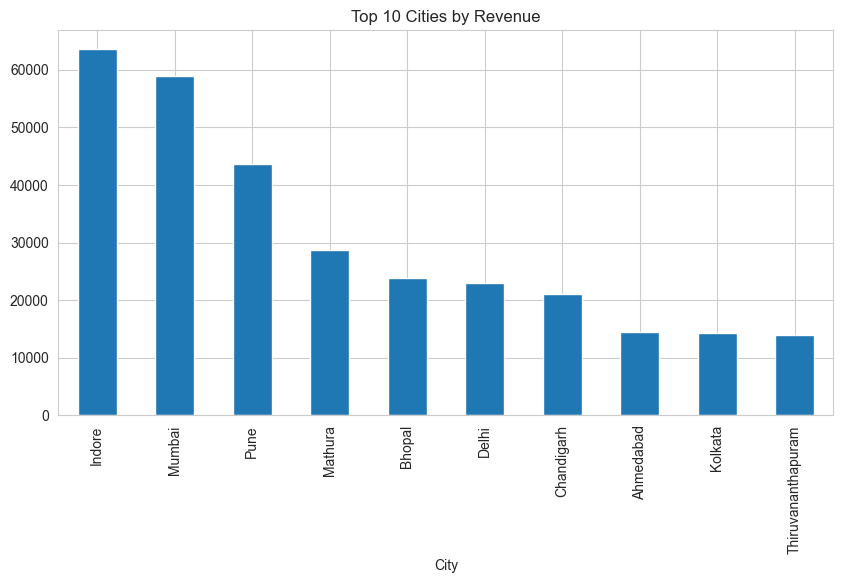

In [ ]:
top_cities.plot(kind="bar", figsize=(10,5))
plt.title("Top 10 Cities by Revenue")
plt.show()

In [ ]:
top_products = df.groupby("Sub-Category")["Revenue"].sum().sort_values(ascending=False).head(10)
top_products

Sub-Category
Printers            59252
Saree               59094
Bookcases           56861
Phones              46119
Electronic Games    39168
Chairs              34222
Trousers            30039
Tables              22614
Accessories         21728
Stole               18546
Name: Revenue, dtype: int64

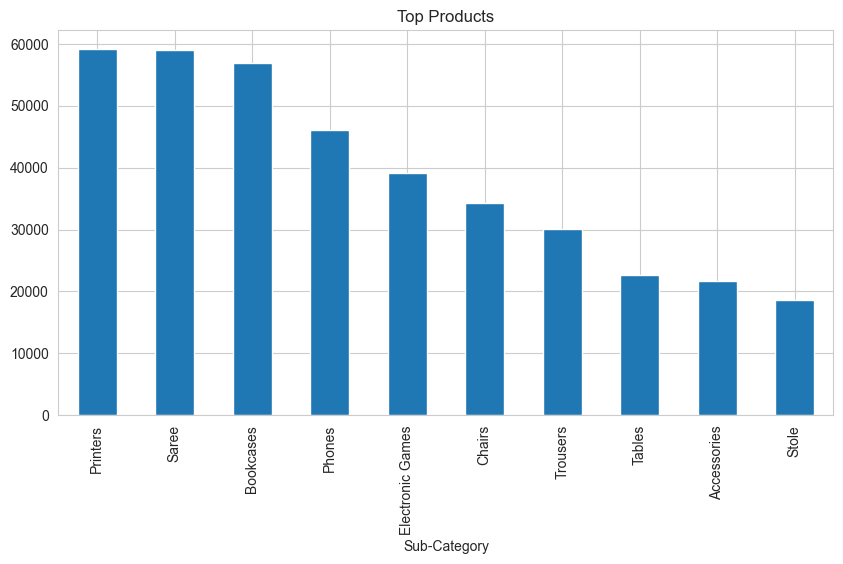

In [ ]:
top_products.plot(kind="bar", figsize=(10,5))
plt.title("Top Products")
plt.show()

# Business Insights

In [ ]:
total_revenue = df["Revenue"].sum()
total_orders = df["Order ID"].nunique()
total_customers = df["CustomerName"].nunique()

avg_order_value = total_revenue / total_orders

print("Total Revenue:", total_revenue)
print("Total Orders:", total_orders)
print("Total Customers:", total_customers)
print("Average Order Value:", avg_order_value)

Total Revenue: 437771
Total Orders: 500
Total Customers: 336
Average Order Value: 875.542


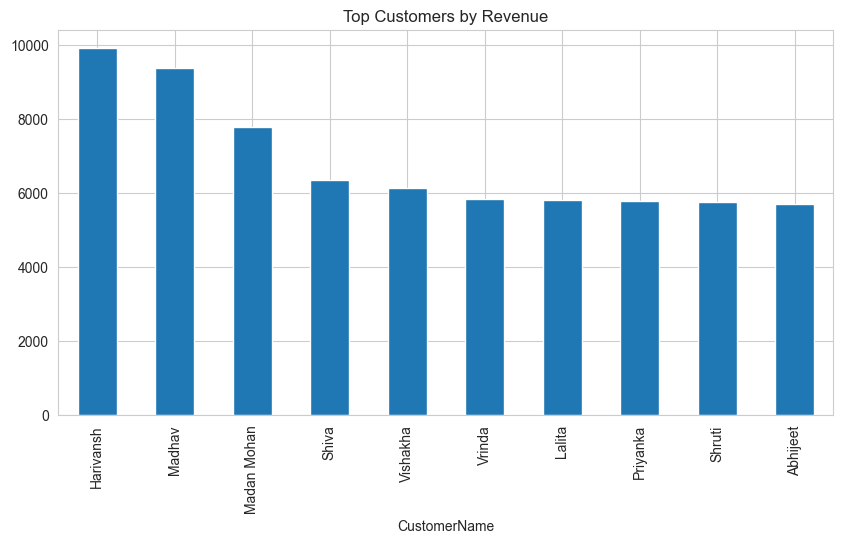

In [ ]:
customer_sales = df.groupby("CustomerName")["Revenue"].sum().sort_values(ascending=False)
top_customers = customer_sales.head(10)

top_customers.plot(kind="bar", figsize=(10,5))
plt.title("Top Customers by Revenue")
plt.show()

## Key Findings

1. Revenue is concentrated in a small number of categories and products.
2. A small group of customers generates a large percentage of total revenue.
3. Sales show a clear monthly trend, suggesting seasonality.
4. Some cities contribute significantly more revenue than others.

## Business Recommendations

• Focus marketing on top cities and high-value customers  
• Increase inventory for top-performing categories  
• Investigate seasonality to plan promotions  
• Develop retention strategies for top customers